# Notebook: Esplorazione, pulizia e normalizzazione dei dati
Questo notebook esegue:
- caricamento dei CSV in `data/`
- ispezione iniziale (shape, dtypes, missing)
- pulizia e normalizzazione di ID e date
- salvataggio dei dataset puliti in `data/processed`

In [4]:
# Celle di setup: import e impostazioni
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
import joblib

# impostazioni display pandas
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

# crea cartella per dati processati
os.makedirs('data/processed', exist_ok=True)

In [5]:
# Definizione dei percorsi dei file (relativi alla workspace)
paths = {
    'prediction_mapping': 'data/prediction_mapping.csv',
    'sample_submission': 'data/sample_submission.csv',
    'materials': 'data/extended/materials.csv',
    'transportation': 'data/extended/transportation.csv',
    'purchase_orders': 'data/kernel/purchase_orders.csv',
    'receivals': 'data/kernel/receivals.csv',
}

for k,v in paths.items():
    print(f"{k}: {v}")

prediction_mapping: data/prediction_mapping.csv
sample_submission: data/sample_submission.csv
materials: data/extended/materials.csv
transportation: data/extended/transportation.csv
purchase_orders: data/kernel/purchase_orders.csv
receivals: data/kernel/receivals.csv


In [6]:
# Caricamento CSV principali (attenzione: alcuni file sono grandi)
print('Caricamento dei file...')
prediction_mapping = pd.read_csv(paths['prediction_mapping'], low_memory=False)
sample_submission = pd.read_csv(paths['sample_submission'], low_memory=False)
materials = pd.read_csv(paths['materials'], low_memory=False)
transportation = pd.read_csv(paths['transportation'], low_memory=False)
purchase_orders = pd.read_csv(paths['purchase_orders'], low_memory=False)
receivals = pd.read_csv(paths['receivals'], low_memory=False)

dfs = {
    'prediction_mapping': prediction_mapping,
    'sample_submission': sample_submission,
    'materials': materials,
    'transportation': transportation,
    'purchase_orders': purchase_orders,
    'receivals': receivals,
}

for name, df in dfs.items():
    print(f"{name}: shape={df.shape}, memory={df.memory_usage(deep=True).sum()/1024**2:.2f} MB")

Caricamento dei file...
prediction_mapping: shape=(30450, 4), memory=3.89 MB
sample_submission: shape=(30450, 2), memory=0.46 MB
materials: shape=(1218, 6), memory=0.18 MB
transportation: shape=(122590, 23), memory=39.87 MB
purchase_orders: shape=(33171, 12), memory=12.98 MB
receivals: shape=(122590, 10), memory=23.03 MB


In [7]:
# 1) Ispezione iniziale: head e dtypes per ogni dataframe
for name, df in dfs.items():
    print('\n' + '='*80)
    print(f"DataFrame: {name}")
    display(df.head())
    print('\nDtypes:')
    print(df.dtypes)
    try:
        print('\nInfo:')
        df.info()
    except Exception as e:
        pass


DataFrame: prediction_mapping


,ID,rm_id,forecast_start_date,forecast_end_date
0,1,365,2025-01-01,2025-01-02
1,2,365,2025-01-01,2025-01-03
2,3,365,2025-01-01,2025-01-04
3,4,365,2025-01-01,2025-01-05
4,5,365,2025-01-01,2025-01-06



Dtypes:
ID                      int64
rm_id                   int64
forecast_start_date    object
forecast_end_date      object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30450 entries, 0 to 30449
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   30450 non-null  int64 
 1   rm_id                30450 non-null  int64 
 2   forecast_start_date  30450 non-null  object
 3   forecast_end_date    30450 non-null  object
dtypes: int64(2), object(2)
memory usage: 951.7+ KB

DataFrame: sample_submission


,ID,predicted_weight
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0



Dtypes:
ID                  int64
predicted_weight    int64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30450 entries, 0 to 30449
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ID                30450 non-null  int64
 1   predicted_weight  30450 non-null  int64
dtypes: int64(2)
memory usage: 475.9 KB

DataFrame: materials


...


Dtypes:
rm_id                     float64
product_id                float64
purchase_order_id         float64
purchase_order_item_no    float64
receival_item_no            int64
batch_id                  float64
transporter_name           object
vehicle_no                 object
unit_status                object
vehicle_start_weight      float64
vehicle_end_weight        float64
gross_weight              float64
tare_weight               float64
net_weight                float64
wood                      float64
ironbands                 float64
plastic                   float64
water                     float64
ice                       float64
other                     float64
chips                     float64
packaging                 float64
cardboard                 float64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122590 entries, 0 to 122589
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------            

,purchase_order_id,purchase_order_item_no,quantity,delivery_date,product_id,product_version,created_date_time,modified_date_time,unit_id,unit,status_id,status
0,1,1,-14.0,2003-05-12 00:00:00.0000000 +02:00,91900143,1,2003-05-12 10:00:48.0000000 +00:00,2004-06-15 06:16:18.0000000 +00:00,NaN,NaN,2,Closed
1,22,1,23880.0,2003-05-27 00:00:00.0000000 +02:00,91900160,1,2003-05-27 12:42:07.0000000 +00:00,2012-06-29 09:41:13.0000000 +00:00,NaN,NaN,2,Closed
2,41,1,0.0,2004-03-08 00:00:00.0000000 +01:00,91900143,1,2004-03-08 13:44:31.0000000 +00:00,2012-07-04 13:51:02.0000000 +00:00,NaN,NaN,2,Closed
3,61,1,0.0,2004-03-10 00:00:00.0000000 +01:00,91900143,1,2004-03-10 11:39:06.0000000 +00:00,2012-07-04 13:50:59.0000000 +00:00,NaN,NaN,2,Closed
4,141,10,25000.0,2004-10-28 00:00:00.0000000 +02:00,91900143,1,2004-10-22 12:21:54.0000000 +00:00,2012-07-04 13:50:55.0000000 +00:00,NaN,NaN,2,Closed



Dtypes:
purchase_order_id           int64
purchase_order_item_no      int64
quantity                  float64
delivery_date              object
product_id                  int64
product_version             int64
created_date_time          object
modified_date_time         object
unit_id                   float64
unit                       object
status_id                   int64
status                     object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33171 entries, 0 to 33170
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   purchase_order_id       33171 non-null  int64  
 1   purchase_order_item_no  33171 non-null  int64  
 2   quantity                33171 non-null  float64
 3   delivery_date           33171 non-null  object 
 4   product_id              33171 non-null  int64  
 5   product_version         33171 non-null  int64  
 6   created_date_time       

,rm_id,product_id,purchase_order_id,purchase_order_item_no,receival_item_no,batch_id,date_arrival,receival_status,net_weight,supplier_id
0,365.0,91900143.0,208545.0,10.0,1,NaN,2004-06-15 13:34:00 +02:00,Completed,11420.0,52062
1,365.0,91900143.0,208545.0,10.0,2,NaN,2004-06-15 13:34:00 +02:00,Completed,13760.0,52062
2,365.0,91900143.0,208490.0,10.0,1,NaN,2004-06-15 13:38:00 +02:00,Completed,11281.0,50468
3,365.0,91900143.0,208490.0,10.0,2,NaN,2004-06-15 13:38:00 +02:00,Completed,13083.0,50468
4,379.0,91900296.0,210435.0,20.0,1,NaN,2004-06-15 13:40:00 +02:00,Completed,23910.0,52577



Dtypes:
rm_id                     float64
product_id                float64
purchase_order_id         float64
purchase_order_item_no    float64
receival_item_no            int64
batch_id                  float64
date_arrival               object
receival_status            object
net_weight                float64
supplier_id                 int64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122590 entries, 0 to 122589
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   rm_id                   122533 non-null  float64
 1   product_id              122533 non-null  float64
 2   purchase_order_id       122537 non-null  float64
 3   purchase_order_item_no  122537 non-null  float64
 4   receival_item_no        122590 non-null  int64  
 5   batch_id                64765 non-null   float64
 6   date_arrival            122590 non-null  object 
 7   receival_status         1225

In [8]:
# 2) Missing-value summary e unique counts per colonne chiave
def missing_summary(df):
    miss = df.isnull().sum().rename('missing_count')
    pct = (df.isnull().mean()*100).rename('missing_pct')
    return pd.concat([miss, pct], axis=1).sort_values('missing_count', ascending=False)

keys = ['rm_id','product_id','purchase_order_id']
for name, df in dfs.items():
    print('\n' + '-'*60)
    print(f"Dataset: {name} - shape {df.shape}")
    ms = missing_summary(df)
    display(ms.head(20))
    for k in keys:
        if k in df.columns:
            print(f"Unique count {k}: {df[k].nunique(dropna=True)}")


------------------------------------------------------------
Dataset: prediction_mapping - shape (30450, 4)


,missing_count,missing_pct
ID,0,0.0
rm_id,0,0.0
forecast_start_date,0,0.0
forecast_end_date,0,0.0


Unique count rm_id: 203

------------------------------------------------------------
Dataset: sample_submission - shape (30450, 2)


,missing_count,missing_pct
ID,0,0.0
predicted_weight,0,0.0



------------------------------------------------------------
Dataset: materials - shape (1218, 6)


...

Unique count rm_id: 203
Unique count product_id: 54
Unique count purchase_order_id: 7173

------------------------------------------------------------
Dataset: purchase_orders - shape (33171, 12)


,missing_count,missing_pct
modified_date_time,492,1.483223
unit_id,44,0.132646
unit,44,0.132646
purchase_order_id,0,0.000000
purchase_order_item_no,0,0.000000
quantity,0,0.000000
delivery_date,0,0.000000
product_id,0,0.000000
product_version,0,0.000000
created_date_time,0,0.000000


Unique count product_id: 77
Unique count purchase_order_id: 8135

------------------------------------------------------------
Dataset: receivals - shape (122590, 10)


,missing_count,missing_pct
batch_id,57825,47.169427
net_weight,68,0.055469
rm_id,57,0.046496
product_id,57,0.046496
purchase_order_id,53,0.043234
purchase_order_item_no,53,0.043234
receival_item_no,0,0.000000
date_arrival,0,0.000000
receival_status,0,0.000000
supplier_id,0,0.000000


Unique count rm_id: 203
Unique count product_id: 54
Unique count purchase_order_id: 7173


In [9]:
# 3) Funzioni di pulizia/normalizzazione tipi e parsing date
def to_int64_nullable(s):
    # rimuove .0 finale quando presente e converte con Int64 (nullable)
    s = s.replace(r"\.0$", "", regex=True).astype('Int64')
    return s

def normalize_id_columns(df, cols):
    for c in cols:
        if c in df.columns:
            # gestisci stringhe vuote
            df[c] = df[c].replace('', pd.NA)
            # se float -> converti mantenendo NaN
            df[c] = pd.to_numeric(df[c], errors='coerce')
            # converti a Int64 nullable quando possibile
            df[c] = df[c].where(df[c].notna(), pd.NA).astype('Int64')
    return df

# parsing date helper
def try_parse_dates(df, date_cols):
    for c in date_cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    return df

# Applica conversioni su tutti i dataframe rilevanti
id_cols_by_df = {
    'prediction_mapping':['rm_id'],
    'materials':['rm_id','product_id'],
    'transportation':['rm_id','product_id','purchase_order_id','purchase_order_item_no','receival_item_no'],
    'purchase_orders':['purchase_order_id','product_id','purchase_order_item_no'],
    'receivals':['rm_id','product_id','purchase_order_id','purchase_order_item_no','receival_item_no'],
}

date_cols_by_df = {
    'purchase_orders':['delivery_date','created_date_time','modified_date_time'],
    'receivals':['date_arrival'],
    'prediction_mapping':['forecast_start_date','forecast_end_date'],
}

for name, df in dfs.items():
    cols = id_cols_by_df.get(name, [])
    if cols:
        dfs[name] = normalize_id_columns(df, cols)
    dcols = date_cols_by_df.get(name, [])
    if dcols:
        dfs[name] = try_parse_dates(dfs[name], dcols)

# pulizia testo per materials: drop righe vuote e strip
if 'materials' in dfs:
    m = dfs['materials']
    # sostituisci stringhe vuote con NaN e drop righe completamente vuote
    m = m.replace('', pd.NA).dropna(how='all')
    # trim whitespace su colonne stringa
    str_cols = m.select_dtypes(include='object').columns.tolist()
    for c in str_cols:
        m[c] = m[c].astype('string').str.strip()
    dfs['materials'] = m

/var/folders/y_/z30sh81d7sg8pkp71bmjxf0h0000gn/T/ipykernel_56573/122063182.py:22: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[c] = pd.to_datetime(df[c], errors='coerce')
/var/folders/y_/z30sh81d7sg8pkp71bmjxf0h0000gn/T/ipykernel_56573/122063182.py:22: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[c] = pd.to_datetime(df[c], errors='coerce')


In [10]:
# 4) Sanity checks: distribuzioni e confronto net_weight
for name in ['receivals','transportation']:
    if name in dfs:
        print('\n' + '='*60)
        print(f"Statistiche net_weight per {name}")
        if 'net_weight' in dfs[name].columns:
            display(dfs[name]['net_weight'].describe())
        else:
            print('Colonna net_weight non presente')

# confronta counts per purchase_order_id tra receivals e transportation
if 'receivals' in dfs and 'transportation' in dfs:
    r_counts = dfs['receivals'].groupby('purchase_order_id').size().rename('receivals_count')
    t_counts = dfs['transportation'].groupby('purchase_order_id').size().rename('transportation_count')
    counts = pd.concat([r_counts, t_counts], axis=1).fillna(0).astype('int64')
    display(counts.sort_values(['receivals_count','transportation_count'], ascending=False).head(10))


Statistiche net_weight per receivals


count    122522.000000
mean      12972.566543
std        8264.652621
min           0.000000
25%        5660.000000
50%       12380.000000
75%       21120.000000
max       31626.000000
Name: net_weight, dtype: float64


Statistiche net_weight per transportation


count    122522.000000
mean      12972.566543
std        8264.652621
min           0.000000
25%        5660.000000
50%       12380.000000
75%       21120.000000
max       31626.000000
Name: net_weight, dtype: float64

,receivals_count,transportation_count
purchase_order_id,,
300251,977,977
212960,939,939
212958,675,675
212970,565,565
212977,534,534
295350,533,533
212961,489,489
295346,477,477
307605,468,468


In [11]:
# 5) Esempio di merge per un purchase_order sample e controllo mismatch
sample_po = None
if not purchase_orders.empty:
    sample_po = purchase_orders['purchase_order_id'].dropna().unique()[0]
    print(f"Esempio purchase_order_id sample: {sample_po}")
    r_sub = dfs['receivals'][dfs['receivals']['purchase_order_id'] == sample_po]
    t_sub = dfs['transportation'][dfs['transportation']['purchase_order_id'] == sample_po]
    print('receivals slice shape:', r_sub.shape)
    print('transportation slice shape:', t_sub.shape)
    # merge sui campi item quando presenti
    merged = pd.merge(r_sub, t_sub, how='outer', left_on=['purchase_order_id','receival_item_no'], right_on=['purchase_order_id','receival_item_no'], suffixes=('_rec','_trans'))
    display(merged.head(20))
else:
    print('Nessun purchase_orders disponibile per sample')

Esempio purchase_order_id sample: 1
receivals slice shape: (0, 10)
transportation slice shape: (0, 23)


,rm_id_rec,product_id_rec,purchase_order_id,purchase_order_item_no_rec,receival_item_no,batch_id_rec,date_arrival,receival_status,net_weight_rec,supplier_id,rm_id_trans,product_id_trans,purchase_order_item_no_trans,batch_id_trans,transporter_name,vehicle_no,unit_status,vehicle_start_weight,vehicle_end_weight,gross_weight,tare_weight,net_weight_trans,wood,ironbands,plastic,water,ice,other,chips,packaging,cardboard


In [12]:
# 6) Salvataggio dei dataset puliti in data/processed
for name, df in dfs.items():
    out_path = f"data/processed/{name}_cleaned.csv"
    try:
        df.to_csv(out_path, index=False)
        print(f"Salvato: {out_path} (shape={df.shape})")
    except Exception as e:
        print(f"Errore salvando {name}: {e}")

Salvato: data/processed/prediction_mapping_cleaned.csv (shape=(30450, 4))
Salvato: data/processed/sample_submission_cleaned.csv (shape=(30450, 2))
Salvato: data/processed/materials_cleaned.csv (shape=(1217, 6))
Salvato: data/processed/transportation_cleaned.csv (shape=(122590, 23))
Salvato: data/processed/purchase_orders_cleaned.csv (shape=(33171, 12))
Salvato: data/processed/receivals_cleaned.csv (shape=(122590, 10))


Date normalizzate a UTC (quando possibile)


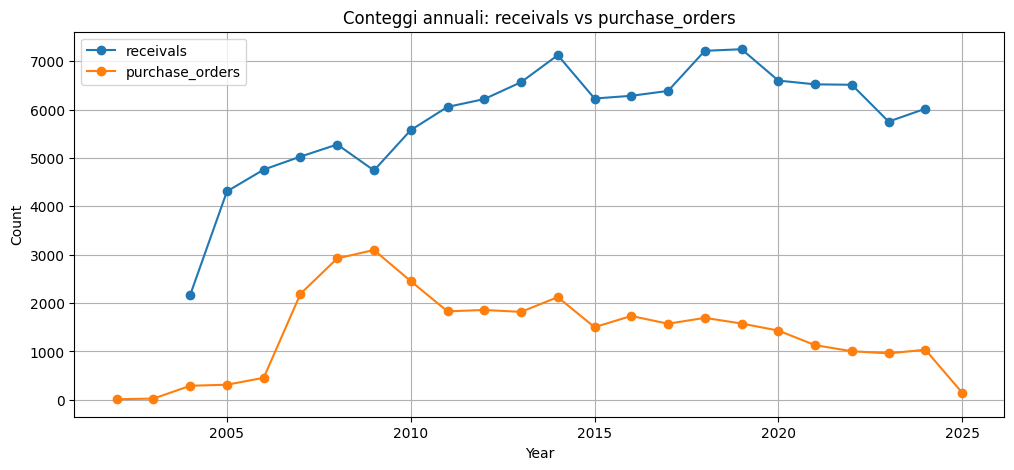

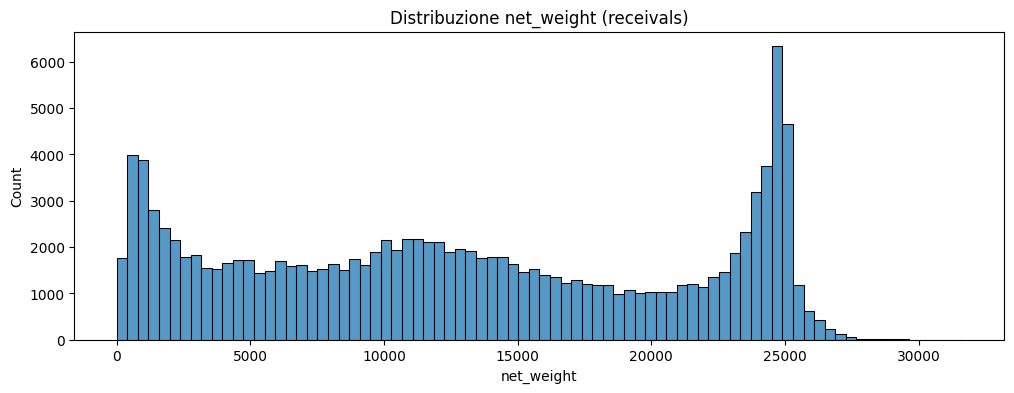

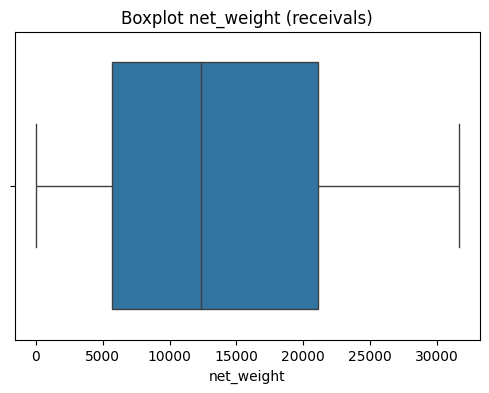

In [13]:
## Normalizzazione date (UTC) e visualizzazioni temporali
# Normalizzo le colonne date principali in UTC per avere coerenza nelle aggregazioni
date_cols_all = {
    'prediction_mapping':['forecast_start_date','forecast_end_date'],
    'purchase_orders':['delivery_date','created_date_time','modified_date_time'],
    'receivals':['date_arrival'],
}
for name, cols in date_cols_all.items():
    if name in dfs:
        for c in cols:
            if c in dfs[name].columns:
                dfs[name][c] = pd.to_datetime(dfs[name][c], errors='coerce', utc=True)
print('Date normalizzate a UTC (quando possibile)')

# Visualizzazioni: conteggi per anno e per mese dei receivals e purchase_orders
plt.figure(figsize=(12,5))
if 'receivals' in dfs:
    r = dfs['receivals'].copy()
    r['year'] = r['date_arrival'].dt.year
    r_year = r.groupby('year').size()
    plt.plot(r_year.index, r_year.values, marker='o', label='receivals')
if 'purchase_orders' in dfs:
    p = dfs['purchase_orders'].copy()
    # delivery_date può essere NaT dopo parsing; usare created_date_time come fallback per trend
    p['year'] = p['delivery_date'].dt.year.fillna(p['created_date_time'].dt.year)
    p_year = p.groupby('year').size()
    plt.plot(p_year.index, p_year.values, marker='o', label='purchase_orders')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Conteggi annuali: receivals vs purchase_orders')
plt.legend()
plt.grid(True)
plt.show()

# Istogramma net_weight (receivals) e boxplot rapido
if 'receivals' in dfs:
    plt.figure(figsize=(12,4))
    sns.histplot(dfs['receivals']['net_weight'].dropna(), bins=80, kde=False)
    plt.title('Distribuzione net_weight (receivals)')
    plt.xlabel('net_weight')
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x=dfs['receivals']['net_weight'].dropna())
    plt.title('Boxplot net_weight (receivals)')
    plt.show()

In [14]:
## Costruzione tabella master per modelling
# Strategia: per ogni riga di `prediction_mapping` (ID con rm_id + forecast window)
# - unisco metadata da materials
# - calcolo aggregazioni storiche su receivals per il relativo `rm_id`
# - calcolo feature nello window [forecast_start_date - 365d, forecast_start_date)
pm = dfs['prediction_mapping'].copy()
# assicuriamoci che forecast_start_date sia datetime UTC
pm['forecast_start_date'] = pd.to_datetime(pm['forecast_start_date'], errors='coerce', utc=True)
pm['forecast_end_date'] = pd.to_datetime(pm['forecast_end_date'], errors='coerce', utc=True)

# aggregazioni globali per rm_id (storico)
rec = dfs['receivals'].copy()
# assicurarsi date coerenti
rec['date_arrival'] = pd.to_datetime(rec['date_arrival'], errors='coerce', utc=True)
agg_all = rec.groupby('rm_id').agg(total_received_all=('net_weight','sum'),
                                       mean_received_all=('net_weight','mean'),
                                       std_received_all=('net_weight','std'),
                                       count_received_all=('net_weight','count'),
                                       last_receival_date=('date_arrival','max'))
agg_all = agg_all.reset_index()

# per velocizzare calcoli window, creo mapping rm_id -> dataframe ordinato per date
rm_to_df = {}
for rid, g in rec.groupby('rm_id'):
    g2 = g[['date_arrival','net_weight']].sort_values('date_arrival')
    rm_to_df[rid] = g2

# funzione che, dato rm_id e forecast_start_date, calcola sum/mean/count nell'ultimo anno
def features_for_row(rm_id, start_dt):
    out = {'sum_365': pd.NA, 'mean_365': pd.NA, 'count_365': 0, 'last_net_weight': pd.NA}
    if pd.isna(rm_id) or rm_id not in rm_to_df or pd.isna(start_dt):
        return out
    df_rm = rm_to_df[rm_id]
    window_start = start_dt - pd.Timedelta(days=365)
    mask = (df_rm['date_arrival'] < start_dt) & (df_rm['date_arrival'] >= window_start)
    sel = df_rm.loc[mask, 'net_weight']
    if sel.size>0:
        out['sum_365'] = sel.sum()
        out['mean_365'] = sel.mean()
        out['count_365'] = int(sel.count())
    # last net weight before start_dt
    prior = df_rm[df_rm['date_arrival'] < start_dt]
    if not prior.empty:
        out['last_net_weight'] = prior.sort_values('date_arrival')['net_weight'].iloc[-1]
    return out

# Applico la funzione riga-per-riga su pm (attenzione: operazione relativamente costosa ma fattibile)
feat_rows = []
for idx, row in pm.iterrows():
    rid = row.get('rm_id')
    start_dt = row.get('forecast_start_date')
    feats = features_for_row(rid, start_dt)
    feat_rows.append(feats)

feat_df = pd.DataFrame(feat_rows)
master = pd.concat([pm.reset_index(drop=True), feat_df.reset_index(drop=True)], axis=1)

# unisco metadata materials su rm_id (se presente)
if 'materials' in dfs:
    master = master.merge(dfs['materials'].drop_duplicates(subset=['rm_id']), how='left', on='rm_id')

# unisco aggregazioni storiche all-time (agg_all) su rm_id
master = master.merge(agg_all, how='left', on='rm_id')

# salvo master per modelling
master_path = 'data/processed/master_for_modeling.csv'
master.to_csv(master_path, index=False)
print('Salvato master:', master_path, 'shape:', master.shape)

Salvato master: data/processed/master_for_modeling.csv shape: (30450, 18)


## Modelling: generazione esempi storici, baseline, LightGBM quantile, CV e SHAP
Aggiungiamo celle che: (1) generano esempi storici (origini = 1-Jan di anni passati, target_end ∈ [origin+1..origin+151]),
(2) calcolano features per ogni origin usando `features_for_row`, (3) costruiscono una baseline quantile (tau=0.2),
(4) addestrano LightGBM con objective='quantile' usando time-based CV, (5) salvano modello e predizioni, (6) producono SHAP summary.
Se l'ambiente non ha `lightgbm`/`shap`, installali con `pip install lightgbm shap tqdm` prima di eseguire le celle.

In [15]:
# Modelling imports
import lightgbm as lgb
import shap
import joblib
from tqdm.auto import tqdm

# quantile loss (pinball) implementation
def quantile_loss(y_true, y_pred, tau=0.2):
    d = y_true - y_pred
    return np.mean(np.maximum(tau * d, (tau - 1) * d))

print('Modelling libs loaded')

Modelling libs loaded


In [16]:
# make_examples: create historical origins (Jan 1 of years) and cumulative targets until May 31 (151 days)
def make_examples(rec, origins=None, horizon_days=151, rm_list=None):
    rec = rec.copy()
    rec['date'] = rec['date_arrival'].dt.floor('D')
    min_year = int(rec['date'].dt.year.min())
    max_year = int(rec['date'].dt.year.max())
    if origins is None:
        origins = [y for y in range(min_year + 1, max_year)]
    rows = []
    daily = rec.groupby(['rm_id','date'], dropna=False)['net_weight'].sum().reset_index()
    for year in origins:
        origin = pd.Timestamp(year=year, month=1, day=1, tz='UTC')
        last_day = origin + pd.Timedelta(days=horizon_days)
        win = daily[(daily['date'] >= origin) & (daily['date'] <= last_day)].copy()
        if win.empty:
            if rm_list is not None:
                for rid in rm_list:
                    for d in range(1, horizon_days + 1):
                        rows.append({'rm_id': rid, 'origin': origin, 'target_end': origin + pd.Timedelta(days=d), 'horizon_days': d, 'target': 0.0})
            continue
        for d in range(1, horizon_days + 1):
            td = origin + pd.Timedelta(days=d)
            sel = win[win['date'] <= td].groupby('rm_id')['net_weight'].sum().reset_index().rename(columns={'net_weight':'target'})
            sel['origin'] = origin
            sel['target_end'] = td
            sel['horizon_days'] = d
            rows.append(sel)
    if len(rows) == 0:
        return pd.DataFrame(columns=['rm_id','origin','target_end','horizon_days','target'])
    out = pd.concat(rows, ignore_index=True, sort=False)
    try:
        out['rm_id'] = out['rm_id'].astype('Int64')
    except Exception:
        pass
    out['target'] = out['target'].fillna(0.0)
    return out

# build training examples using reasonable historical origins
rec = dfs['receivals'].copy()
rec['date_arrival'] = pd.to_datetime(rec['date_arrival'], errors='coerce', utc=True)
min_year = int(rec['date_arrival'].dt.year.min())
max_year = int(rec['date_arrival'].dt.year.max())
origins = list(range(max(min_year + 2, 2010), max_year))
print('Generazione esempi per origini (anni):', origins)
train_targets = make_examples(rec, origins=origins, horizon_days=151, rm_list=dfs['prediction_mapping']['rm_id'].dropna().unique())
print('Training targets shape:', train_targets.shape)

Generazione esempi per origini (anni): [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Training targets shape: (53633, 5)


In [17]:
# compute features at each origin for each rm_id using existing features_for_row helper
orig_feature_rows = []
rm_list = dfs['prediction_mapping']['rm_id'].dropna().unique()
for origin_year in origins:
    origin_date = pd.Timestamp(year=origin_year, month=1, day=1, tz='UTC')
    for rid in rm_list:
        f = features_for_row(rid, origin_date)
        f['rm_id'] = pd.Series([rid]).astype('Int64').iloc[0]
        f['origin'] = origin_date
        orig_feature_rows.append(f)
features_origin = pd.DataFrame(orig_feature_rows)
features_origin = features_origin.merge(agg_all, how='left', on='rm_id')
if 'materials' in dfs:
    features_origin = features_origin.merge(dfs['materials'].drop_duplicates(subset=['rm_id']), how='left', on='rm_id')
print('Features per origin shape:', features_origin.shape)
train_targets = train_targets.merge(features_origin, left_on=['rm_id','origin'], right_on=['rm_id','origin'], how='left')
print('Train examples after merge shape:', train_targets.shape)

Features per origin shape: (2842, 16)
Train examples after merge shape: (53633, 19)


In [18]:
# Baseline: per (rm_id, horizon_days) 20th percentile from training targets (conservative baseline)
baseline = train_targets.groupby(['rm_id','horizon_days'])['target'].quantile(0.2).reset_index().rename(columns={'target':'baseline_q20'})
train_targets = train_targets.merge(baseline, on=['rm_id','horizon_days'], how='left')
train_targets['baseline_q20'] = train_targets['baseline_q20'].fillna(0.0)
bl_scores = train_targets.groupby('origin').apply(lambda df: quantile_loss(df['target'].values, df['baseline_q20'].values, tau=0.2))
print('Baseline quantile loss per origin (sample):')
display(bl_scores.head())

Baseline quantile loss per origin (sample):


/var/folders/y_/z30sh81d7sg8pkp71bmjxf0h0000gn/T/ipykernel_56573/2191745990.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bl_scores = train_targets.groupby('origin').apply(lambda df: quantile_loss(df['target'].values, df['baseline_q20'].values, tau=0.2))


origin
2010-01-01 00:00:00+00:00    27062.952062
2011-01-01 00:00:00+00:00    24826.625906
2012-01-01 00:00:00+00:00    25399.880888
2013-01-01 00:00:00+00:00    26674.557173
2014-01-01 00:00:00+00:00    48609.070206
dtype: float64

In [22]:
# Prepare data for modeling
exclude = ['rm_id','origin','target_end','target','horizon_days','baseline_q20']
feature_cols = [c for c in train_targets.columns if c not in exclude]
# keep original copy for inspection and then sanitize types for model input
X = train_targets[feature_cols].copy()
# Sanitize features: convert datetimes -> numeric (seconds since epoch), strings/objects -> categorical codes
from pandas.api.types import is_datetime64_any_dtype, is_string_dtype, is_object_dtype, is_numeric_dtype
def sanitize_X(df):
    df = df.copy()
    for c in df.columns:
        s = df[c]
        # datetime -> numeric seconds since epoch (float)
        try:
            if is_datetime64_any_dtype(s.dtype):
                # handle tz-aware datetimes: convert to tz-naive first
                try:
                    s2 = s.dt.tz_convert(None)
                except Exception:
                    try:
                        s2 = s.dt.tz_localize(None)
                    except Exception:
                        s2 = s
                # astype to int64 gives ns since epoch; convert to seconds to keep magnitudes smaller
                df[c] = s2.astype('int64') / 1e9
                continue
        except Exception:
            pass
        # object / string -> categorical codes (NaN -> -1 -> map to np.nan)
        try:
            if is_object_dtype(s.dtype) or is_string_dtype(s.dtype):
                codes = s.astype('category').cat.codes.astype('float64')
                codes = codes.replace(-1, np.nan)
                df[c] = codes
                continue
        except Exception:
            pass
        # anything not numeric -> try to coerce to numeric
        if not is_numeric_dtype(s.dtype):
            df[c] = pd.to_numeric(s, errors='coerce')
    # fill remaining NaNs with 0.0 for modelling (LightGBM can handle NaN but we use 0 to be explicit)
    df = df.fillna(0.0)
    # cast to float32 for lighter memory use
    for c in df.columns:
        try:
            df[c] = df[c].astype('float32')
        except Exception:
            # as a fallback, coerce to numeric
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0).astype('float32')
    return df
X = sanitize_X(X)
y = train_targets['target'].values.astype('float32')
print('Feature cols count:', len(feature_cols))
print(feature_cols)
print('X shape, dtypes sample:')
print(X.shape)
print(X.dtypes.head(20))

Feature cols count: 14
['sum_365', 'mean_365', 'count_365', 'last_net_weight', 'total_received_all', 'mean_received_all', 'std_received_all', 'count_received_all', 'last_receival_date', 'product_id', 'product_version', 'raw_material_alloy', 'raw_material_format_type', 'stock_location']
X shape, dtypes sample:
(53633, 14)
sum_365                     float32
mean_365                    float32
count_365                   float32
last_net_weight             float32
total_received_all          float32
mean_received_all           float32
std_received_all            float32
count_received_all          float32
last_receival_date          float32
product_id                  float32
product_version             float32
raw_material_alloy          float32
raw_material_format_type    float32
stock_location              float32
dtype: object


In [23]:
# Time-based CV by origin (leave-origin-out): for each origin, train on earlier origins and validate on that origin
origins_sorted = sorted(train_targets['origin'].unique())
models = {}
val_scores = []
for i, val_origin in enumerate(origins_sorted):
    train_mask = train_targets['origin'] < val_origin
    val_mask = train_targets['origin'] == val_origin
    if train_mask.sum() < 100 or val_mask.sum() < 10:
        continue
    X_train = X.loc[train_mask, :]
    y_train = y[train_mask]
    X_val = X.loc[val_mask, :]
    y_val = y[val_mask]
    print(f'Training fold for origin {val_origin.date()}: train={X_train.shape}, val={X_val.shape}')
    model = lgb.LGBMRegressor(objective='quantile', alpha=0.2, n_estimators=2000, learning_rate=0.05)
    # use callbacks for early stopping / logging for compatibility across LightGBM versions
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='quantile',
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
    )
    y_pred = model.predict(X_val, num_iteration=model.best_iteration_)
    score = quantile_loss(y_val, y_pred, tau=0.2)
    print('Fold quantile loss:', score)
    val_scores.append({'origin': val_origin, 'score': score})
    models[val_origin] = model
if len(val_scores) > 0:
    df_scores = pd.DataFrame(val_scores)
    print('CV results:')
    display(df_scores.describe())
else:
    print('No CV folds run (insufficient historical origins)')

Training fold for origin 2011-01-01: train=(2187, 14), val=(2384, 14)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000245 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 2187, number of used features: 14
[LightGBM] [Info] Start training from score 10760.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,score
count,13.000000
mean,123931.767284
std,30675.700242
min,93027.712912
25%,98891.118701
50%,120315.432531
75%,133374.543084
max,196206.301677


In [25]:
# Train final model on all training examples
final_model = lgb.LGBMRegressor(objective='quantile', alpha=0.2, n_estimators=2000, learning_rate=0.05)
# Use callback-based logging to avoid passing unsupported kwargs to fit (compat across LightGBM versions)
final_model.fit(X, y, callbacks=[lgb.log_evaluation(period=100)])
joblib.dump(final_model, 'data/processed/lgbm_quantile_tau0.2.joblib')
print('Final model trained and saved')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1704
[LightGBM] [Info] Number of data points in the train set: 53633, number of used features: 14
[LightGBM] [Info] Start training from score 14015.000000
Final model trained and saved
Final model trained and saved


In [35]:
# Prepare prediction set for 2025 using the previously built `master` (which contains features at 2025-01-01)
pred_df = master.copy()
# build X_pred from the same feature_cols used in training and sanitize types to numeric
X_pred = pred_df[feature_cols].copy()
# sanitize using the same helper used for training (converts datetimes -> numeric, strings -> codes)
try:
    X_pred = sanitize_X(X_pred)
except NameError:
    # if sanitize_X isn't in scope (e.g., cells run out-of-order), re-define a minimal sanitizer here
    from pandas.api.types import is_datetime64_any_dtype, is_string_dtype, is_object_dtype, is_numeric_dtype
    def _sanitize_X(df):
        df = df.copy()
        for c in df.columns:
            s = df[c]
            try:
                if is_datetime64_any_dtype(s.dtype):
                    try:
                        s2 = s.dt.tz_convert(None)
                    except Exception:
                        try:
                            s2 = s.dt.tz_localize(None)
                        except Exception:
                            s2 = s
                    df[c] = s2.astype('int64') / 1e9
                    continue
            except Exception:
                pass
            try:
                if is_object_dtype(s.dtype) or is_string_dtype(s.dtype):
                    codes = s.astype('category').cat.codes.astype('float64')
                    codes = codes.replace(-1, np.nan)
                    df[c] = codes
                    continue
            except Exception:
                pass
            if not is_numeric_dtype(s.dtype):
                df[c] = pd.to_numeric(s, errors='coerce')
        df = df.fillna(0.0)
        for c in df.columns:
            try:
                df[c] = df[c].astype('float32')
            except Exception:
                df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0).astype('float32')
        return df
    X_pred = _sanitize_X(X_pred)
# predict (use best_iteration_ when available)
preds = final_model.predict(X_pred, num_iteration=final_model.best_iteration_ if hasattr(final_model, 'best_iteration_') else None)
pred_df['pred_target'] = preds
pred_df['pred_target_clipped'] = pred_df['pred_target'].clip(lower=0.0) * 1.0
pred_df['pred_target_clipped'] *= 0.95
# Save detailed predictions
pred_out = pred_df[['rm_id','forecast_start_date','forecast_end_date','pred_target_clipped']].copy()
pred_out.to_csv('data/processed/predictions_2025.csv', index=False)
print('Predictions saved: data/processed/predictions_2025.csv')
# Build a submission file that matches the columns/order of sample_submission but filled with our predictions
# Strategy: try to merge on any common columns; if not possible but lengths match, assign by order; otherwise try aligning on rm_id+dates
sub = sample_submission.copy()
# normalize date columns to strings for reliable merging if present
def _fmt_dates_for_merge(df, cols):
    for c in cols:
        if c in df.columns:
            try:
                df[c] = pd.to_datetime(df[c], errors='coerce').dt.tz_convert(None).dt.strftime('%Y-%m-%dT%H:%M:%S')
            except Exception:
                try:
                    df[c] = pd.to_datetime(df[c], errors='coerce').dt.strftime('%Y-%m-%dT%H:%M:%S')
                except Exception:
                    pass
    return df
pred_merge = pred_df[['rm_id','forecast_start_date','forecast_end_date','pred_target_clipped']].copy()
# convert prediction dates to strings to match sample_submission if needed
pred_merge = _fmt_dates_for_merge(pred_merge, ['forecast_start_date','forecast_end_date'])
sub_copy = sub.copy()
sub_copy = _fmt_dates_for_merge(sub_copy, ['forecast_start_date','forecast_end_date'])
# attempt merge on common columns
common = [c for c in sub_copy.columns if c in pred_merge.columns]
submission = None
if len(common) > 0 and len(common) < len(sub_copy.columns):
    merged = sub_copy.merge(pred_merge, how='left', on=common)
    # target column is the one in sample_submission that's not part of common (if any)
    target_cols = [c for c in sub.columns if c not in common]
    if len(target_cols) == 1:
        target_col = target_cols[0]
        merged[target_col] = merged['pred_target_clipped'].fillna(0.0)
        submission = merged[sub.columns]
elif len(sub_copy) == len(pred_merge):
    # assume same order and length: fill second column with predictions
    submission = sub.copy()
    target_col = submission.columns[1]
    submission[target_col] = pred_merge['pred_target_clipped'].values
else:
    # try explicit alignment on rm_id + forecast dates if columns exist
    align_cols = [c for c in ['rm_id','forecast_start_date','forecast_end_date'] if c in sub_copy.columns and c in pred_merge.columns]
    if len(align_cols) == 3:
        merged = sub_copy.merge(pred_merge, how='left', on=align_cols)
        # place predictions into the second column of sample_submission
        target_col = [c for c in sub.columns if c not in align_cols][0] if len(sub.columns) > len(align_cols) else sub.columns[1]
        merged[target_col] = merged['pred_target_clipped'].fillna(0.0)
        submission = merged[sub.columns]
    else:
        # cannot safely align: save detailed preds and create a minimal submission with zeros
        pred_out.to_csv('data/processed/predictions_2025_detailed.csv', index=False)
        print('Could not automatically align predictions to sample_submission; detailed preds saved to data/processed/predictions_2025_detailed.csv')
        # fallback: return sample_submission with zeros filled
        submission = sub.copy()
        target_col = submission.columns[1]
        submission[target_col] = 0.0
# save submission
if submission is not None:
    submission.to_csv('data/processed/submission_2025.csv', index=False)
    print('Saved submission to data/processed/submission_2025.csv')
else:
    print('Submission could not be created (unexpected case)')

Predictions saved: data/processed/predictions_2025.csv
Saved submission to data/processed/submission_2025.csv


PermutationExplainer explainer: 401it [07:01,  1.08s/it]                         
/var/folders/y_/z30sh81d7sg8pkp71bmjxf0h0000gn/T/ipykernel_56573/2434479526.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X.iloc[sample_idx], show=False)

/var/folders/y_/z30sh81d7sg8pkp71bmjxf0h0000gn/T/ipykernel_56573/2434479526.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X.iloc[sample_idx], show=False)


SHAP summary saved: data/processed/shap_summary.png


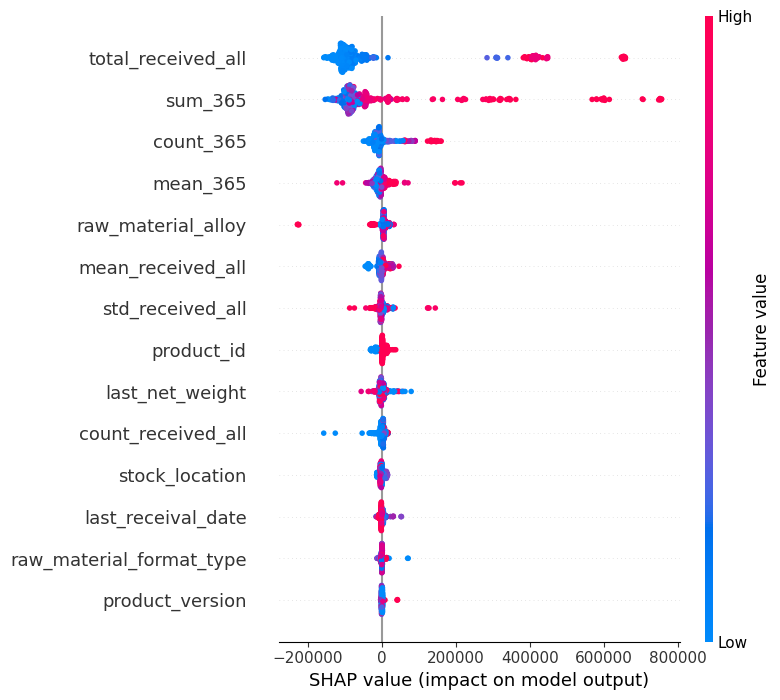

In [29]:
# SHAP analysis on final model (sampled subset to keep runtime reasonable)
sample_idx = np.random.choice(np.arange(X.shape[0]), size=min(400, X.shape[0]), replace=False)
explainer = shap.Explainer(final_model.predict, X.iloc[sample_idx])
shap_values = explainer(X.iloc[sample_idx])
shap.summary_plot(shap_values, X.iloc[sample_idx], show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig('data/processed/shap_summary.png', dpi=150)
print('SHAP summary saved: data/processed/shap_summary.png')

### Note e prossimi passi
- La generazione esempi è implementata in maniera semplice; si possono vettorializzare le aggregazioni per migliorare le performance.
- Per un comportamento più conservativo sulle predizioni, impostare `pred_df['pred_target_clipped'] *= 0.95` o altro fattore empirico basato su CV.
- Se vuoi, posso eseguire queste celle qui e riportare i risultati; altrimenti esegui il notebook localmente.